In [4]:
%%capture
%pip install gensim

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from gensim.models import KeyedVectors

# load pretrained word2vec (GoogleNews or your own)
# model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)
emo_words= ['depressed','alarmed','aroused','pleased','serene','astonished',
            'miserable','content','excited','angry','tired','bored',
            'afraid','delighted','satisfied','calm','glad','distressed',
            'annoyed','droopy','gloomy','sleepy','frustrated','amused']

emo_categories = [3,2,1,4,4,1,
                  3,4,1,2,3,3,
                  2,1,4,4,1,2,
                  2,3,3,4,2,1]

import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")  # ~70MB, loads automatically

# sort by category (same as before)
sort_idx = np.argsort(emo_categories)
emo_words_sorted = [emo_words[i] for i in sort_idx]
emo_cat_sorted = [emo_categories[i] for i in sort_idx]

n = len(emo_words)
RSM = np.zeros((n, n))



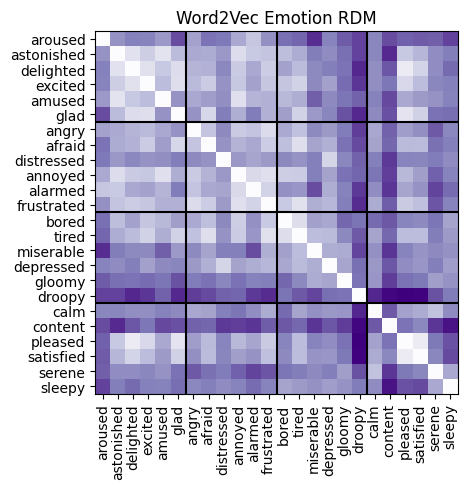

In [16]:

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

for i in range(n):
    for j in range(n):
        wi = emo_words_sorted[i]
        wj = emo_words_sorted[j]

        try:
            vec_i = model[wi]
            vec_j = model[wj]

            # cosine distance (1 - similarity)
            RSM[i, j] = cosine(vec_i, vec_j)

        except KeyError:
            # handle missing words
            RSM[i, j] = np.nan


# plot
im = ax.imshow(RSM, cmap='Purples')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(emo_words_sorted, rotation=90)
ax.set_yticklabels(emo_words_sorted)

# draw category boundaries
cat_changes = np.where(np.diff(emo_cat_sorted))[0] + 1
for b in cat_changes:
    ax.axhline(b - 0.5, color='black')
    ax.axvline(b - 0.5, color='black')

ax.set_title('Word2Vec Emotion RDM')

plt.tight_layout()
plt.show()